In [1]:
import numpy as np
import pandas as pd

import shap
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [4]:
model = joblib.load("C:/Users/Durosimi/PROJECTS/Parkinson/models/final_motor_updrs_groupcv.pkl")
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/featured_data.csv")

In [6]:
features = [
     "jitter",
    "shimmer",
    "hnr",
    "rpde",
    "ppe",
    "sex"
]

X = data[features]
y = data["motor_updrs"]

In [8]:
explainer = shap.TreeExplainer(model.named_steps["model"])
shap_values = explainer.shap_values(
    model.named_steps["scaler"].transform(X)
)

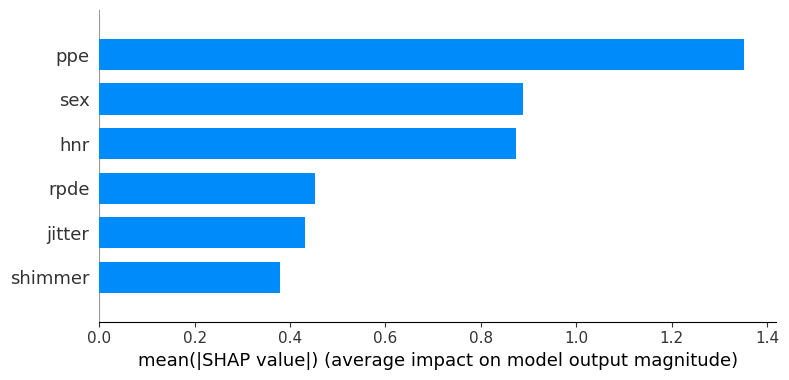

In [30]:
shap.summary_plot(
    shap_values,
    model.named_steps["scaler"].transform(X),
    feature_names=features,
    plot_type="bar"
)

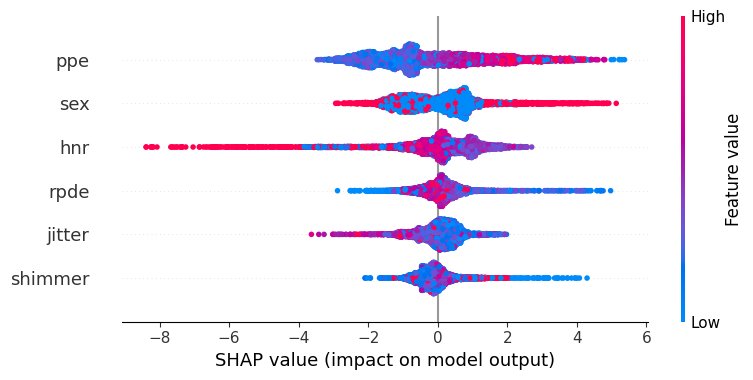

In [16]:
shap.summary_plot(
    shap_values,
    model.named_steps["scaler"].transform(X),
    feature_names=features
)


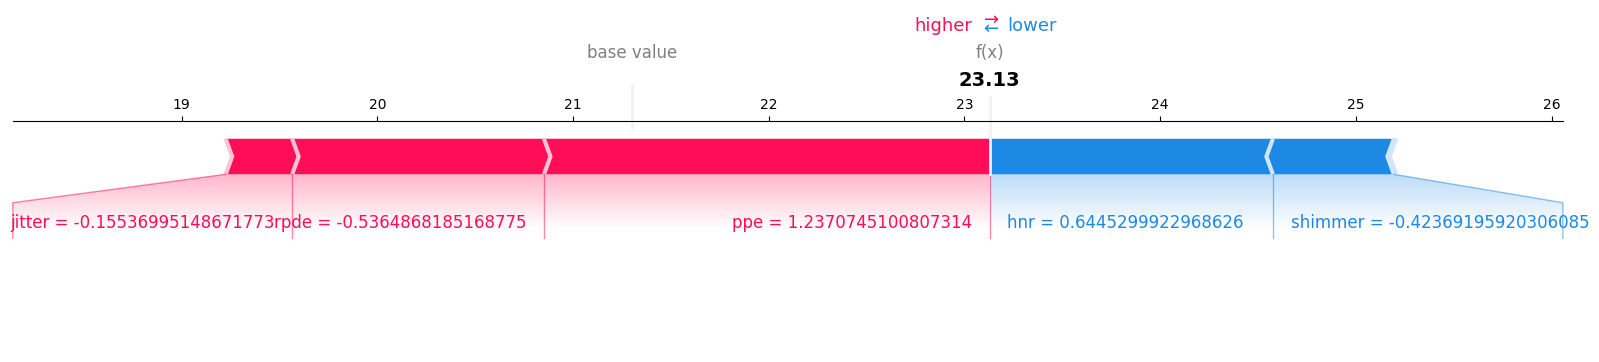

In [34]:
idx = 3

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    model.named_steps["scaler"].transform(X)[idx],
    feature_names=features,
    matplotlib=True
)


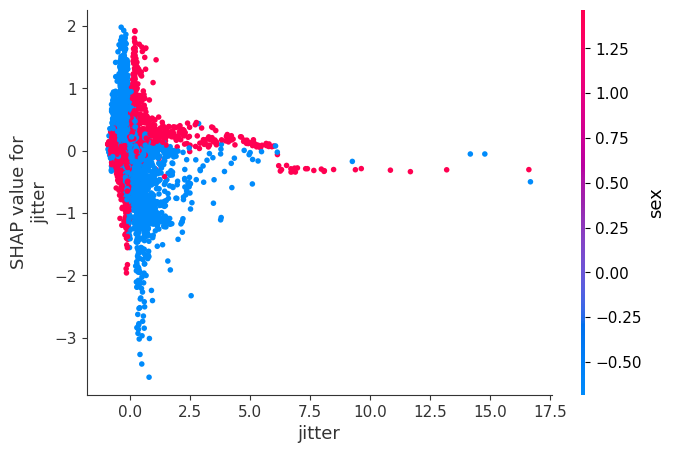

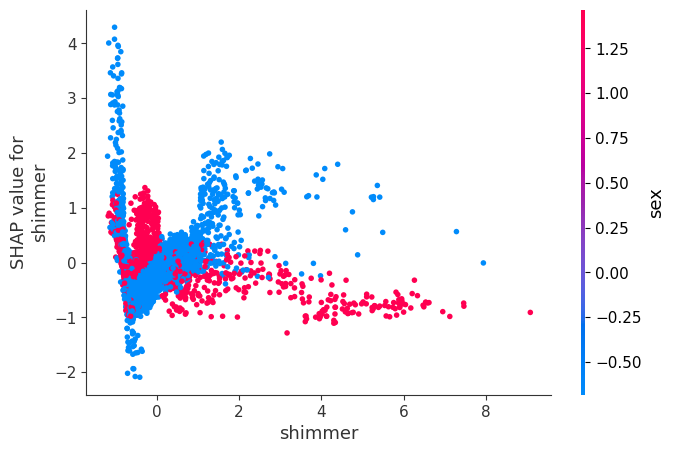

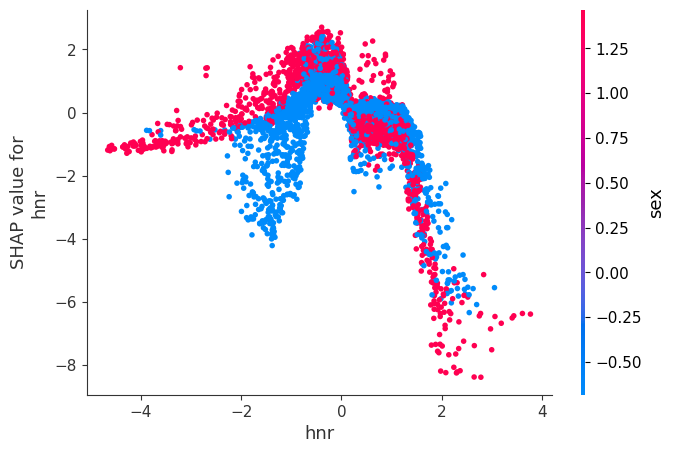

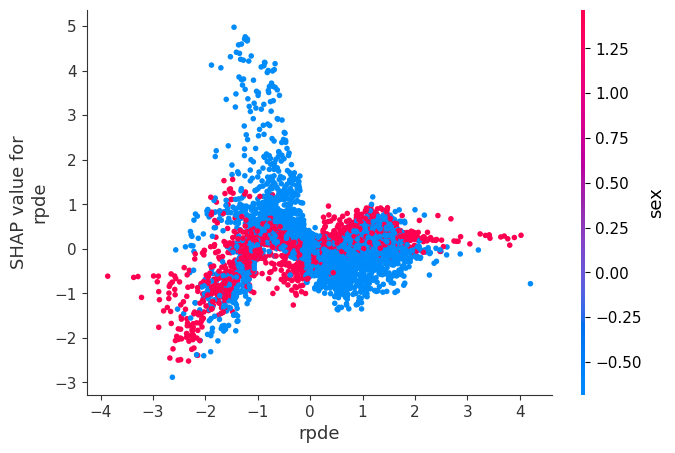

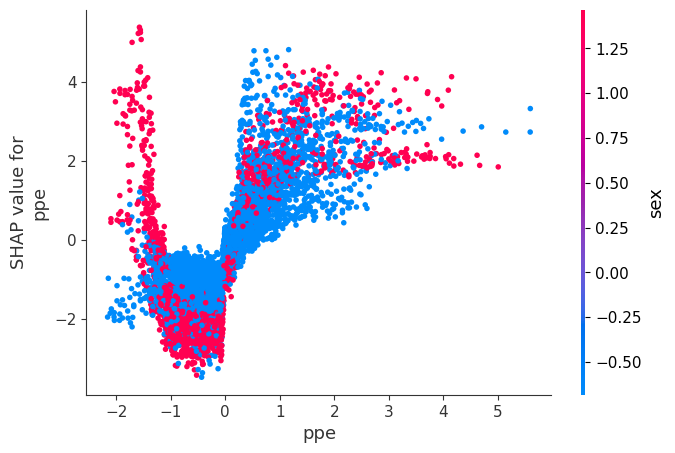

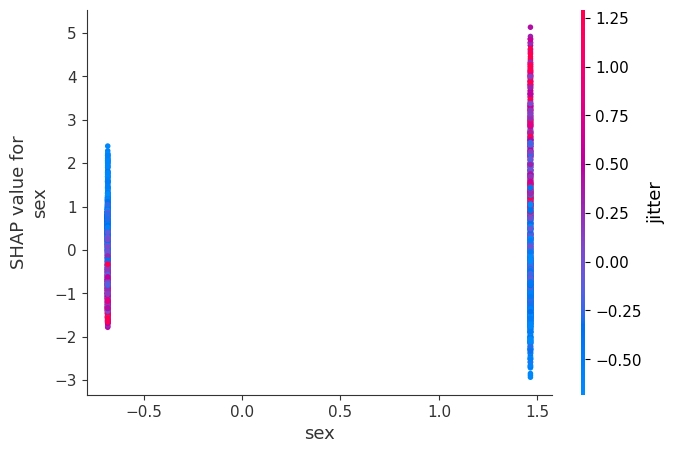

In [37]:
for feature in features:
    shap.dependence_plot(
        feature,
        shap_values,
        model.named_steps["scaler"].transform(X),
        feature_names=features
    )


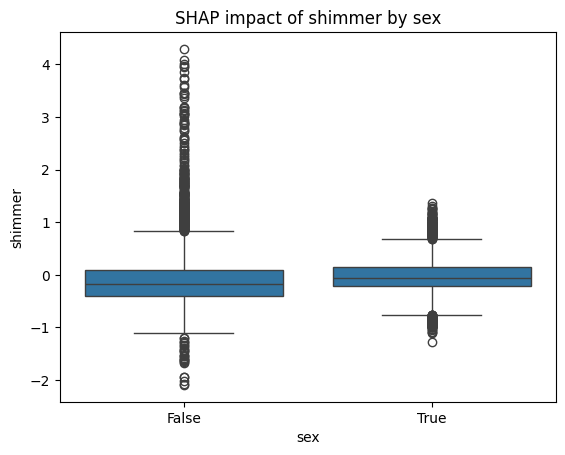

In [44]:
df_shap = pd.DataFrame(
    shap_values,
    columns=features
)

df_shap["sex"] = data["sex"].values

sns.boxplot(
    x="sex",
    y="shimmer",
    data=df_shap
)
plt.title("SHAP impact of shimmer by sex")
plt.show()


### SHAP analysis indicates that voice perturbation measures (jitter, shimmer, RPDE) contribute most strongly to motor UPDRS predictions. Higher jitter and shimmer values generally increase predicted motor impairment, while higher harmonic-to-noise ratio (HNR) is associated with lower predicted severity. Sex has a comparatively small but non-zero contribution.